## Using Subset of fashion MNIST dataset

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset , DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [5]:
df=pd.read_csv("fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [6]:
df.shape

(6000, 785)

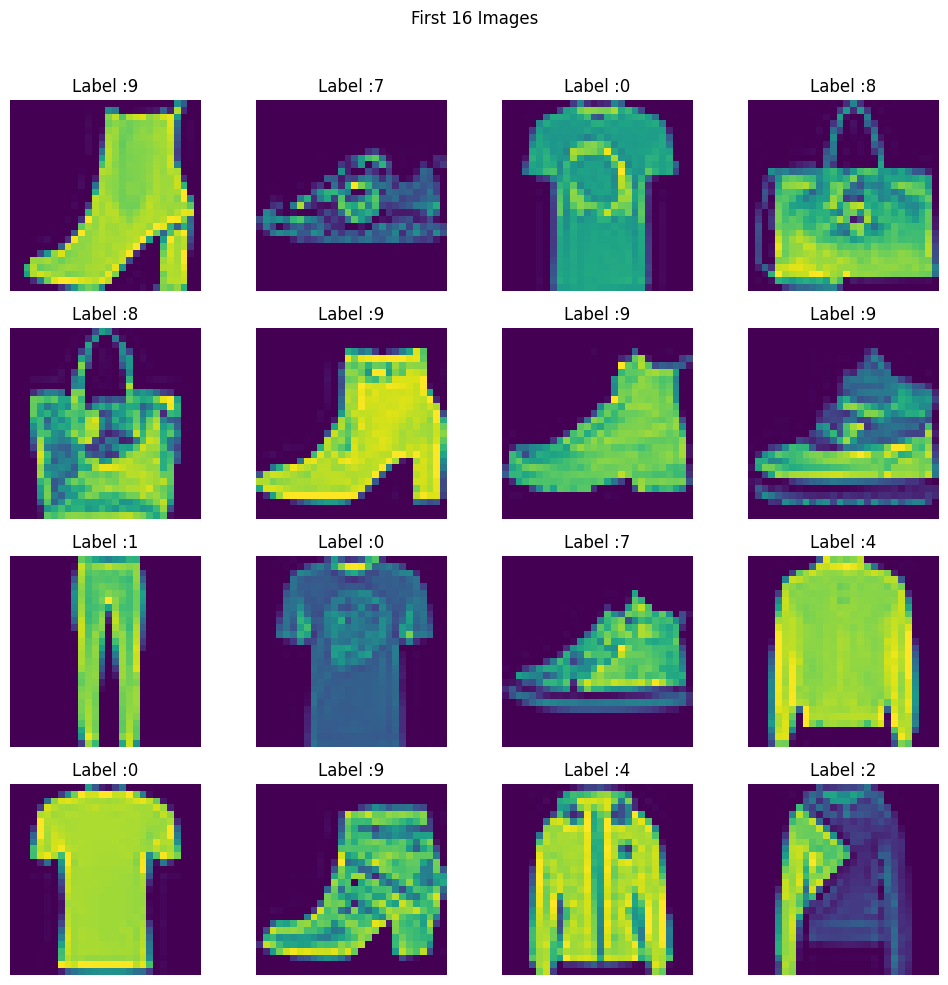

In [7]:
# Creating a 4x4 grid of images
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 Images")

# Plotting first 16 images
for i,ax in enumerate(axes.flat):
  img=df.iloc[i,1:].values.reshape(28,28) # reshape to 28 x 28 image
  ax.imshow(img) # Display in grayscale
  ax.axis('off')  #Remove axis for a cleaner look
  ax.set_title(f"Label :{df.iloc[i,0]}") #show label

plt.tight_layout(rect=[0,0,1,0.96]) # adjust layout to fit the title
plt.show()


In [8]:
X=df.iloc[:,1:].values
y=df.iloc[:,0].values


In [9]:
X.shape

(6000, 784)

In [10]:
x_train,x_test,y_train ,y_test =train_test_split(X,y,test_size=0.2, random_state=42)


In [11]:
# Scaling the features
x_train=x_train/255.0 # Dividing x_train with larget value
x_test=x_test/255.0

In [12]:
x_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

In [13]:
x_train.shape

(4800, 784)

In [14]:
x_test.shape

(1200, 784)

In [15]:
# Create CustomDataset  Class
class CustomDataset(Dataset):
  def __init__(self,features,label):
    self.features=torch.tensor(features,dtype=torch.float32)
    self.label=torch.tensor(label,dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self,index):

    return self.features[index], self.label[index]


In [16]:
#Create Train & test Dataset Object
train_dataset=CustomDataset(x_train,y_train)
test_dataset=CustomDataset(x_test,y_test)


In [17]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [18]:
#creating train and test data loader
train_loader=DataLoader(train_dataset, batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32, shuffle=False)


In [19]:
# Define NN class
class MyNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model=nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
        )

  def forward(self,x):
    return self.model(x)

In [20]:
epochs=100
learning_rate=0.1


In [21]:
#instatiate the model
model=MyNN(x_train.shape[1])

#loss function
criterion=nn.CrossEntropyLoss()

#optimizer
optimizer =optim.SGD(model.parameters(),lr=learning_rate)

In [22]:
len(train_loader)

150

In [23]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 1.321636847257614
Epoch: 2 , Loss: 0.7793365468581518
Epoch: 3 , Loss: 0.642752461830775
Epoch: 4 , Loss: 0.575165734688441
Epoch: 5 , Loss: 0.5278772555788358
Epoch: 6 , Loss: 0.49531099627415337
Epoch: 7 , Loss: 0.46192684849103294
Epoch: 8 , Loss: 0.4355264962216218
Epoch: 9 , Loss: 0.4189064339796702
Epoch: 10 , Loss: 0.39741519580284757
Epoch: 11 , Loss: 0.38665723691383996
Epoch: 12 , Loss: 0.3712777954339981
Epoch: 13 , Loss: 0.34902072300513587
Epoch: 14 , Loss: 0.3476298316816489
Epoch: 15 , Loss: 0.3158551316956679
Epoch: 16 , Loss: 0.31195787246028583
Epoch: 17 , Loss: 0.2958236759901047
Epoch: 18 , Loss: 0.2882651353875796
Epoch: 19 , Loss: 0.2712535948306322
Epoch: 20 , Loss: 0.25993845276534555
Epoch: 21 , Loss: 0.25771099572380385
Epoch: 22 , Loss: 0.2449994078775247
Epoch: 23 , Loss: 0.2397058691829443
Epoch: 24 , Loss: 0.22276731016735235
Epoch: 25 , Loss: 0.22197383304437002
Epoch: 26 , Loss: 0.21040236316621302
Epoch: 27 , Loss: 0.22004777260124683
E

In [24]:
# set model to evaluation mode
model.eval()


MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [27]:
# evaluation code
total=0
correct=0
with torch.no_grad(): # to avoid updation of parameters while predicting
  for batch_features , batch_label in test_loader:
    outputs=model(batch_features)

    _,predicted=torch.max(outputs,1) # returns two values max value , indices in tensor form

    total=total+batch_features.shape[0]
    correct=correct + (predicted==batch_label).sum().item() # add all the correct output

print(correct/total)


0.8333333333333334
